## Loading the Data

In [1]:
import os

# base = "/kaggle/input"
# for item in os.listdir(base):
#     print(item)

In [2]:
# dataset_root = "/kaggle/input/datasets/marccrastoD/ataQu-segmentation-data/Chest X-ray dataset for lung segmentation"
dataset_root = "/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation"

for root, dirs, files in os.walk(dataset_root):
    print(root, len(files))
    if len(files) > 0:
        print("  sample files:", files[:3])

/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation 1
  sample files: ['utils.py']
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen 0
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen 0
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen/ann 566
  sample files: ['CHNCXR_0176_0.png.json', 'CHNCXR_0287_0.png.json', 'CHNCXR_0389_1.png.json']
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen/mask 566
  sample files: ['CHNCXR_0092_0.png', 'CHNCXR_0322_0.png', 'CHNCXR_0304_0.png']
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen/img 566
  sample files: ['CHNCXR_0092_0.png', 'CHNCXR_0322_0.png', 'CHNCXR_0304_0.png']
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Darwin 0
/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Darwin/Darwin 0
/ka

In [3]:
dataset_roots = [
    "/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Darwin/Darwin",
    "/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Montgomery/Montgomery",
    "/kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen",
]

## Sanity Check

In [4]:
import os

for root in dataset_roots:
    img_dir = os.path.join(root, "img")
    mask_dir = os.path.join(root, "mask")

    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    mask_files = set([f for f in os.listdir(mask_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

    missing = [f for f in img_files if f not in mask_files]
    extra_masks = [f for f in mask_files if f not in set(img_files)]

    print(f"\nDataset: {root}")
    print("Images:", len(img_files))
    print("Masks:", len(mask_files))
    print("Missing masks:", len(missing))
    print("Extra masks:", len(extra_masks))

    if missing:
        print("Missing examples:", missing[:10])
    if extra_masks:
        print("Extra mask examples:", extra_masks[:10])


Dataset: /kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Darwin/Darwin
Images: 6106
Masks: 6106
Missing masks: 0
Extra masks: 0

Dataset: /kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Montgomery/Montgomery
Images: 138
Masks: 138
Missing masks: 0
Extra masks: 0

Dataset: /kaggle/input/private-dataset/Chest X-ray dataset for lung segmentation/Shenzhen/Shenzhen
Images: 566
Masks: 566
Missing masks: 0
Extra masks: 0


## Dataset Class

In [5]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class LungSegmentationDataset(Dataset):
    def __init__(self, dataset_roots, image_size=256):
        self.samples = []
        self.image_size = image_size

        for root in dataset_roots:
            img_dir = os.path.join(root, "img")
            mask_dir = os.path.join(root, "mask")

            if not os.path.isdir(img_dir):
                raise FileNotFoundError(f"Missing img folder: {img_dir}")
            if not os.path.isdir(mask_dir):
                raise FileNotFoundError(f"Missing mask folder: {mask_dir}")

            image_names = sorted([
                f for f in os.listdir(img_dir)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ])

            for image_name in image_names:
                image_path = os.path.join(img_dir, image_name)
                mask_path = os.path.join(mask_dir, image_name)

                if os.path.exists(mask_path):
                    self.samples.append((image_path, mask_path))
                else:
                    print(f"Warning: missing mask for {image_name}")

        if len(self.samples) == 0:
            raise ValueError("No image-mask pairs found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")
        if mask is None:
            raise FileNotFoundError(f"Could not read mask: {mask_path}")

        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        image = np.expand_dims(image, axis=0)   # (1, H, W)
        mask = np.expand_dims(mask, axis=0)     # (1, H, W)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

Total samples: 6810
Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


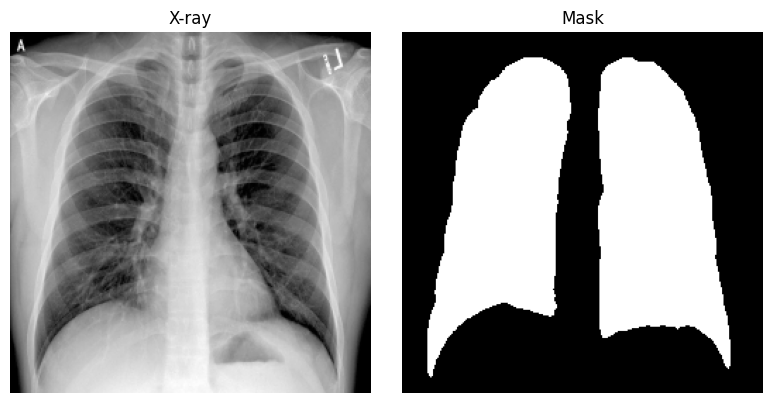

In [6]:
import matplotlib.pyplot as plt
import torch

dataset = LungSegmentationDataset(dataset_roots, image_size=256)

print("Total samples:", len(dataset))

image, mask = dataset[0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image min/max:", image.min().item(), image.max().item())
print("Mask unique values:", torch.unique(mask))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(0), cmap="gray")
plt.title("X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(0), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## Train/Val Split

In [7]:
from torch.utils.data import random_split, DataLoader

full_dataset = LungSegmentationDataset(dataset_roots, image_size=256)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 5448
Val size: 1362


## Define U-Net

In [8]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final_conv = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

## Loss (BCE + Dice)

In [9]:
import torch.nn.functional as F

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()

def combined_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    d = dice_loss(logits, targets)
    return bce + d

## Training Setup

In [10]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 12
best_val_loss = float("inf")

## Training Loop

In [11]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Val"):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = combined_loss(logits, masks)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_unet.pth")
        print("Saved best model.")

Epoch 1/12 Val: 100%|██████████| 171/171 [00:17<00:00,  9.76it/s]


Epoch 1: train_loss=0.2873, val_loss=0.1973
Saved best model.


Epoch 2/12 Val: 100%|██████████| 171/171 [00:09<00:00, 17.39it/s]


Epoch 2: train_loss=0.1686, val_loss=0.1599
Saved best model.


Epoch 3/12 Val: 100%|██████████| 171/171 [00:09<00:00, 17.44it/s]


...

Epoch 10: train_loss=0.1303, val_loss=0.1561


Epoch 11/12 Val: 100%|██████████| 171/171 [00:09<00:00, 17.17it/s]


Epoch 11: train_loss=0.1275, val_loss=0.1316
Saved best model.


Epoch 12/12 Val: 100%|██████████| 171/171 [00:09<00:00, 17.34it/s]

Epoch 12: train_loss=0.1242, val_loss=0.1334


## Generate Pseudo-Masks

In [12]:
import os
import cv2
import numpy as np
import torch
from tqdm import tqdm

os.makedirs("/kaggle/working/nih_imgs", exist_ok=True)
os.makedirs("/kaggle/working/nih_masks", exist_ok=True)

seg_model = UNet(in_channels=1, out_channels=1).to(device)
seg_model.load_state_dict(torch.load("/kaggle/working/best_unet.pth", map_location=device))
seg_model.eval()

idx = 0
with torch.no_grad():
    for images, _ in tqdm(train_loader, desc="Generating masks for train"):
        images = images.to(device)
        masks = (torch.sigmoid(seg_model(images)) > 0.5).float()
        for i in range(len(images)):
            img_np = (images[i].squeeze().cpu().numpy() * 255).astype(np.uint8)
            mask_np = (masks[i].squeeze().cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(f"/kaggle/working/nih_imgs/{idx:05d}.png", img_np)
            cv2.imwrite(f"/kaggle/working/nih_masks/{idx:05d}.png", mask_np)
            idx += 1
    for images, _ in tqdm(val_loader, desc="Generating masks for val"):
        images = images.to(device)
        masks = (torch.sigmoid(seg_model(images)) > 0.5).float()
        for i in range(len(images)):
            img_np = (images[i].squeeze().cpu().numpy() * 255).astype(np.uint8)
            mask_np = (masks[i].squeeze().cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(f"/kaggle/working/nih_imgs/{idx:05d}.png", img_np)
            cv2.imwrite(f"/kaggle/working/nih_masks/{idx:05d}.png", mask_np)
            idx += 1

print(f"Generated {idx} image-mask pairs")

Generating masks for val: 100%|██████████| 171/171 [00:11<00:00, 14.67it/s]

Generated 6810 image-mask pairs


##  Create folders and copy files

In [13]:
import os
import shutil

os.makedirs("/kaggle/working/nih_data/img", exist_ok=True)
os.makedirs("/kaggle/working/nih_data/mask", exist_ok=True)

for f in os.listdir("/kaggle/working/nih_imgs"):
    shutil.copy(f"/kaggle/working/nih_imgs/{f}", f"/kaggle/working/nih_data/img/{f}")

for f in os.listdir("/kaggle/working/nih_masks"):
    shutil.copy(f"/kaggle/working/nih_masks/{f}", f"/kaggle/working/nih_data/mask/{f}")

print("Done! img:", len(os.listdir("/kaggle/working/nih_data/img")))
print("Done! mask:", len(os.listdir("/kaggle/working/nih_data/mask")))

Done! img: 6810
Done! mask: 6810


## Retrain U-Net on NIH pseudo-masks

In [14]:
dataset_roots = ["/kaggle/working/nih_data"]
nih_seg_dataset = LungSegmentationDataset(dataset_roots, image_size=256)
train_size = int(0.8 * len(nih_seg_dataset))
val_size = len(nih_seg_dataset) - train_size
train_seg, val_seg = random_split(nih_seg_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42))
train_seg_loader = DataLoader(train_seg, batch_size=16, shuffle=True, num_workers=2)
val_seg_loader = DataLoader(val_seg, batch_size=16, shuffle=False, num_workers=2)

model_nih = UNet(in_channels=1, out_channels=1).to(device)
model_nih.load_state_dict(torch.load("/kaggle/working/best_unet.pth", map_location=device))
optimizer_nih = torch.optim.Adam(model_nih.parameters(), lr=1e-4)
best_val_loss = float("inf")
num_epochs = 10

for epoch in range(num_epochs):
    model_nih.train()
    train_loss = 0.0
    for images, masks in tqdm(train_seg_loader, desc=f"Epoch {epoch+1} Train"):
        images, masks = images.to(device), masks.to(device)
        optimizer_nih.zero_grad()
        loss = combined_loss(model_nih(images), masks)
        loss.backward()
        optimizer_nih.step()
        train_loss += loss.item()
    train_loss /= len(train_seg_loader)
    model_nih.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_seg_loader, desc=f"Epoch {epoch+1} Val"):
            images, masks = images.to(device), masks.to(device)
            val_loss += combined_loss(model_nih(images), masks).item()
    val_loss /= len(val_seg_loader)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_nih.state_dict(), "/kaggle/working/best_unet_nih.pth")
        print("Saved best model.")

Epoch 1 Val: 100%|██████████| 86/86 [00:08<00:00,  9.60it/s]


Epoch 1: train_loss=0.0308, val_loss=0.0236
Saved best model.


Epoch 2 Val: 100%|██████████| 86/86 [00:08<00:00,  9.59it/s]


Epoch 2: train_loss=0.0240, val_loss=0.0215
Saved best model.


Epoch 3 Val: 100%|██████████| 86/86 [00:08<00:00,  9.61it/s]


...

Epoch 8: train_loss=0.0197, val_loss=0.0187
Saved best model.


Epoch 9 Val: 100%|██████████| 86/86 [00:08<00:00,  9.59it/s]


Epoch 9: train_loss=0.0194, val_loss=0.0181
Saved best model.


Epoch 10 Val: 100%|██████████| 86/86 [00:08<00:00,  9.59it/s]

Epoch 10: train_loss=0.0191, val_loss=0.0192


## Visualize Predictions

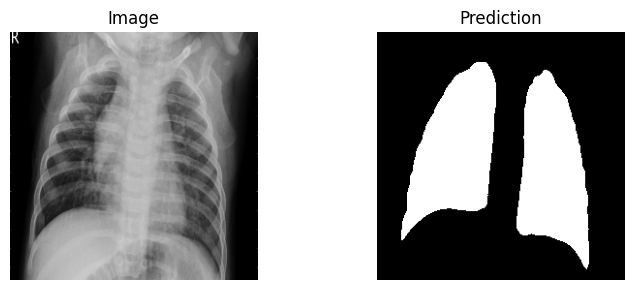

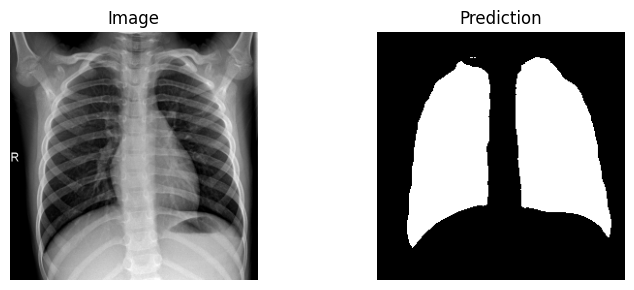

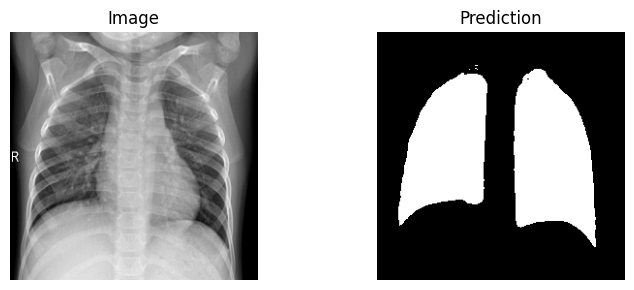

In [15]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("/kaggle/input/datasets/junyongha/best-unet/best_unet.pth", map_location=device))
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = (torch.sigmoid(model(images)) > 0.5).float()

images = images.cpu()
preds = preds.cpu()

for i in range(min(3, len(images))):
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title("Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(preds[i].squeeze(0), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Build Dataset for Classification

In [16]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "/kaggle/input/datasets/danielmadmon/nih-chest-xray-13-labels/Classes"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

## Build Classifier

In [17]:
import torch.nn as nn
class LungClassifier(nn.Module):
    def __init__(self, num_classes=13):
        super().__init__()
        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0, 5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.pool1(self.enc1(x))
        x = self.pool2(self.enc2(x))
        x = self.pool3(self.enc3(x))
        return self.classifier(x)

## Training the Classifier without Unet Model and Masking

In [18]:
classifier = LungClassifier(num_classes=13).to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
best_val_loss = float("inf")

for epoch in range(10):
    classifier.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    classifier.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Train"):
            images, labels = images.to(device), labels.to(device)
            outputs = classifier(images)
            val_loss += criterion(outputs, labels).item()
        val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(classifier.state_dict(), "/kaggle/working/best_classifier_noseg.pth")
        print("Saved best model.")

Epoch 1 Train: 100%|██████████| 345/345 [01:12<00:00,  4.75it/s]


Epoch 1: train_loss=2.2887, val_loss=2.2424
Saved best model.


Epoch 2 Train: 100%|██████████| 345/345 [00:51<00:00,  6.68it/s]


Epoch 2: train_loss=2.2129, val_loss=2.2046
Saved best model.


Epoch 3 Train: 100%|██████████| 345/345 [00:51<00:00,  6.65it/s]


...

Epoch 8: train_loss=2.0945, val_loss=2.1260
Saved best model.


Epoch 9 Train: 100%|██████████| 345/345 [00:51<00:00,  6.68it/s]


Epoch 9: train_loss=2.0790, val_loss=2.0999
Saved best model.


Epoch 10 Train: 100%|██████████| 345/345 [00:50<00:00,  6.77it/s]

Epoch 10: train_loss=2.0577, val_loss=2.1021


## Training the Classifier with Unet Model and Masking

In [19]:
from torch.utils.data import TensorDataset

classifier = LungClassifier(num_classes=13).to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
best_val_loss = float("inf")

seg_model = UNet(in_channels=1, out_channels=1).to(device)
seg_model.load_state_dict(torch.load("/kaggle/working/best_unet_nih.pth", map_location=device))
seg_model.eval()

def precompute_masked_dataset(loader, seg_model, device):
    all_images = []
    all_labels = []
    seg_model.eval()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Precomputing masks"):
            images = images.to(device)
            masks = (torch.sigmoid(seg_model(images)) > 0.5).float()
            masked = (images * masks).cpu()
            all_images.append(masked)
            all_labels.append(labels)
    return TensorDataset(torch.cat(all_images), torch.cat(all_labels))

train_masked = precompute_masked_dataset(train_loader, seg_model, device)
val_masked = precompute_masked_dataset(val_loader, seg_model, device)
train_loader_masked = DataLoader(train_masked, batch_size=16, shuffle=True, num_workers=2)
val_loader_masked = DataLoader(val_masked, batch_size=16, shuffle=False, num_workers=2)

for epoch in range(10):
    classifier.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader_masked, desc=f"Epoch {epoch+1} Train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_masked)
    classifier.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader_masked, desc=f"Epoch {epoch+1} Val"):
            images, labels = images.to(device), labels.to(device)
            outputs = classifier(images)
            val_loss += criterion(outputs, labels).item()
    val_loss /= len(val_loader_masked)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(classifier.state_dict(), "/kaggle/working/best_classifier.pth")
        print("Saved best model.")
classifier_seg = classifier

Epoch 1 Val: 100%|██████████| 345/345 [00:11<00:00, 30.63it/s]


Epoch 1: train_loss=2.2886, val_loss=2.2714
Saved best model.


Epoch 2 Val: 100%|██████████| 345/345 [00:11<00:00, 30.63it/s]


Epoch 2: train_loss=2.2137, val_loss=2.3002


Epoch 3 Val: 100%|██████████| 345/345 [00:11<00:00, 30.63it/s]


...

Epoch 8: train_loss=2.0992, val_loss=2.1398


Epoch 9 Val: 100%|██████████| 345/345 [00:11<00:00, 30.59it/s]


Epoch 9: train_loss=2.0888, val_loss=2.1354


Epoch 10 Val: 100%|██████████| 345/345 [00:11<00:00, 30.61it/s]


Epoch 10: train_loss=2.0798, val_loss=2.0904
Saved best model.


## Visualize Predictions

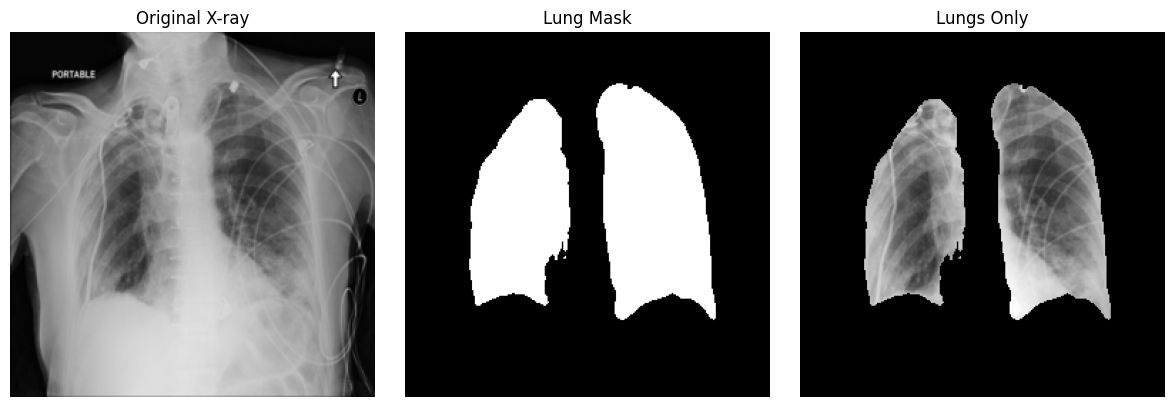

In [20]:
image, _ = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    mask = (torch.sigmoid(seg_model(image)) > 0.5).float()

masked_image = image * mask

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image.squeeze().cpu(), cmap="gray")
axes[0].set_title("Original X-ray")
axes[0].axis("off")

axes[1].imshow(mask.squeeze().cpu(), cmap="gray")
axes[1].set_title("Lung Mask")
axes[1].axis("off")

axes[2].imshow(masked_image.squeeze().cpu(), cmap="gray")
axes[2].set_title("Lungs Only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## GradCam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


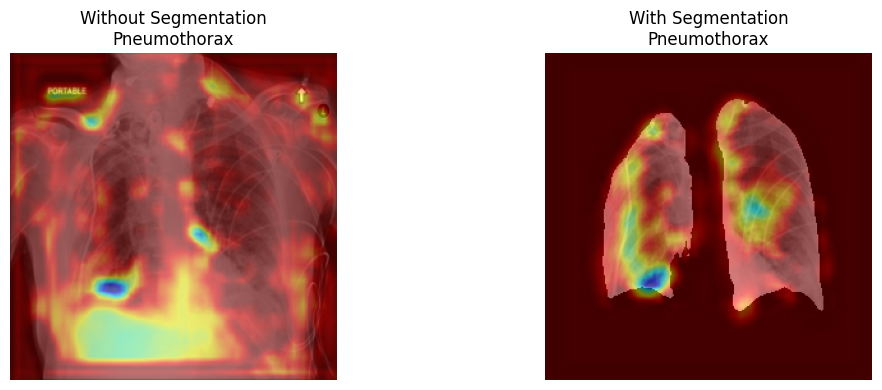

In [21]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layers = [classifier_seg.enc3.block[-1]]
cam = GradCAM(model=classifier_seg, target_layers=target_layers)

image, label = val_dataset[0]
image_tensor = image.unsqueeze(0).to(device)
with torch.no_grad():
    mask = (torch.sigmoid(seg_model(image_tensor)) > 0.5).float()
image_tensor = image_tensor * mask

grayscale_cam = cam(input_tensor=image_tensor)
img_np = image_tensor.squeeze().cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
img_rgb = np.stack([img_np]*3, axis=-1)
visualization = show_cam_on_image(img_rgb, grayscale_cam[0])

image, label = val_dataset[0]
image_tensor_orig = image.unsqueeze(0).to(device)

classifier_noseg = LungClassifier(num_classes=13).to(device)
classifier_noseg.load_state_dict(torch.load("/kaggle/working/best_classifier_noseg.pth", map_location=device))

target_layers_noseg = [classifier_noseg.enc3.block[-1]]
cam_noseg = GradCAM(model=classifier_noseg, target_layers=target_layers_noseg)
grayscale_cam_noseg = cam_noseg(input_tensor=image_tensor_orig)

img_orig_np = image_tensor_orig.squeeze().cpu().numpy()
img_orig_np = (img_orig_np - img_orig_np.min()) / (img_orig_np.max() - img_orig_np.min())
img_orig_rgb = np.stack([img_orig_np]*3, axis=-1)
visualization_noseg = show_cam_on_image(img_orig_rgb, grayscale_cam_noseg[0])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(visualization_noseg)
plt.title(f"Without Segmentation\n{full_dataset.classes[label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"With Segmentation\n{full_dataset.classes[label]}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Metrics

In [22]:
from sklearn.metrics import accuracy_score, f1_score

# Load models fresh from disk
classifier_noseg = LungClassifier(num_classes=13).to(device)
classifier_noseg.load_state_dict(torch.load("/kaggle/working/best_classifier_noseg.pth", map_location=device))

classifier_seg = LungClassifier(num_classes=13).to(device)
classifier_seg.load_state_dict(torch.load("/kaggle/working/best_classifier.pth", map_location=device))

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# val_loader = original images (no mask)
# val_loader_masked = precomputed masked images
preds_noseg, labels = evaluate_model(classifier_noseg, val_loader)
preds_seg, _ = evaluate_model(classifier_seg, val_loader_masked)

print("WITHOUT segmentation:")
print(f"  Accuracy: {accuracy_score(labels, preds_noseg):.4f}")
print(f"  F1 Score: {f1_score(labels, preds_noseg, average='macro'):.4f}")

print("\nWITH segmentation:")
print(f"  Accuracy: {accuracy_score(labels, preds_seg):.4f}")
print(f"  F1 Score: {f1_score(labels, preds_seg, average='macro'):.4f}")

Evaluating: 100%|██████████| 345/345 [00:11<00:00, 30.46it/s]

WITHOUT segmentation:
  Accuracy: 0.2889
  F1 Score: 0.1336

WITH segmentation:
  Accuracy: 0.2983
  F1 Score: 0.1416
